In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")


In [4]:
train_df = pd.read_csv("dataset_C_training (1).csv")
test_df = pd.read_csv("dataset_C_testing.csv")
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print(train_df.head())
print(test_df.head())


Train shape: (4756, 31)
Test shape: (4749, 30)
   respondent_id  covid_concern  covid_knowledge  behavioral_antiviral_meds  \
0              1            3.0              1.0                        0.0   
1              2            2.0              1.0                        0.0   
2              3            0.0              2.0                        0.0   
3              4            2.0              2.0                        0.0   
4              5            1.0              1.0                        0.0   

   behavioral_avoidance  behavioral_face_mask  behavioral_wash_hands  \
0                   1.0                   0.0                    1.0   
1                   1.0                   0.0                    1.0   
2                   0.0                   0.0                    0.0   
3                   1.0                   0.0                    1.0   
4                   1.0                   0.0                    0.0   

   behavioral_large_gatherings  behavioral_ou

In [6]:
print(train_df.info())
print(train_df.describe(include="all"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4756 entries, 0 to 4755
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   respondent_id                 4756 non-null   int64  
 1   covid_concern                 4744 non-null   float64
 2   covid_knowledge               4729 non-null   float64
 3   behavioral_antiviral_meds     4742 non-null   float64
 4   behavioral_avoidance          4729 non-null   float64
 5   behavioral_face_mask          4754 non-null   float64
 6   behavioral_wash_hands         4747 non-null   float64
 7   behavioral_large_gatherings   4746 non-null   float64
 8   behavioral_outside_home       4742 non-null   float64
 9   behavioral_touch_face         4735 non-null   float64
 10  chronic_med_condition         4587 non-null   float64
 11  child_under_6_months          4621 non-null   float64
 12  health_worker                 4624 non-null   float64
 13  hea

In [8]:
missing_train = train_df.isnull().sum().sort_values(ascending=False)
missing_train_pct = (train_df.isnull().mean() * 100).sort_values(ascending=False)
missing_summary = pd.DataFrame({
    "missing_count": missing_train,
    "missing_pct": missing_train_pct
})
print(missing_summary[missing_summary["missing_count"] > 0])

                              missing_count  missing_pct
employment_sector                      2330    48.990749
health_insurance                       1908    40.117746
income_poverty                          748    15.727502
rent_or_own                             329     6.917578
employment_status                       238     5.004205
marital_status                          231     4.857023
education                               228     4.793944
chronic_med_condition                   169     3.553406
child_under_6_months                    135     2.838520
health_worker                           132     2.775442
opinion_covid_sick_from_vacc             90     1.892347
household_adults                         39     0.820017
household_children                       39     0.820017
behavioral_avoidance                     27     0.567704
covid_knowledge                          27     0.567704
behavioral_touch_face                    21     0.441548
behavioral_outside_home        

covid_vaccine
0    3202
1    1554
Name: count, dtype: int64
covid_vaccine
0    67.325484
1    32.674516
Name: proportion, dtype: float64


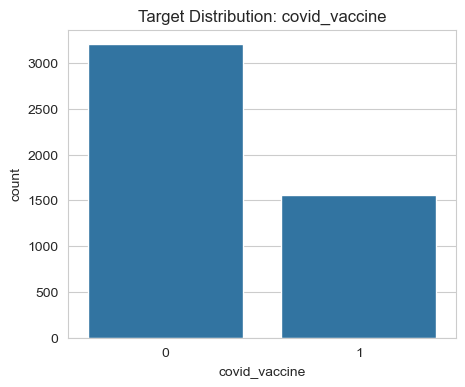

In [10]:
target_col = "covid_vaccine"
print(train_df[target_col].value_counts())
print(train_df[target_col].value_counts(normalize=True) * 100)
plt.figure(figsize=(5,4))
sns.countplot(x=target_col, data=train_df)
plt.title("Target Distribution: covid_vaccine")
plt.show()

In [12]:
drop_cols = ["respondent_id", target_col]
X = train_df.drop(columns=drop_cols, errors="ignore")
y = train_df[target_col]
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object"]).columns.tolist()
print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: ['age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 'employment_status', 'census_msa', 'employment_sector']
Numeric columns: ['covid_concern', 'covid_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands', 'behavioral_large_gatherings', 'behavioral_outside_home', 'behavioral_touch_face', 'chronic_med_condition', 'child_under_6_months', 'health_worker', 'health_insurance', 'household_adults', 'household_children', 'doctor_recc_covid', 'opinion_covid_vacc_effective', 'opinion_covid_risk', 'opinion_covid_sick_from_vacc']


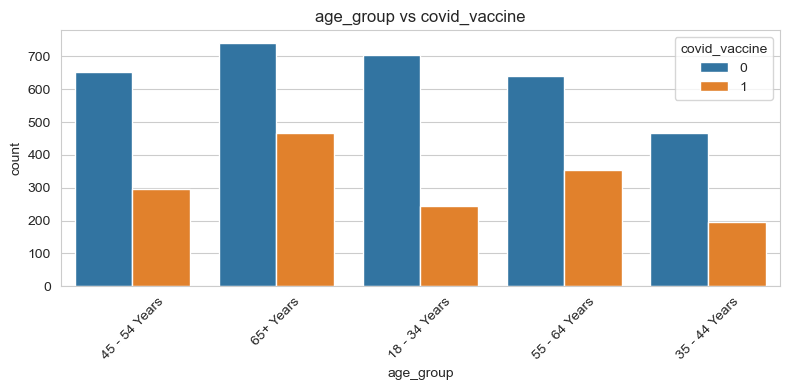

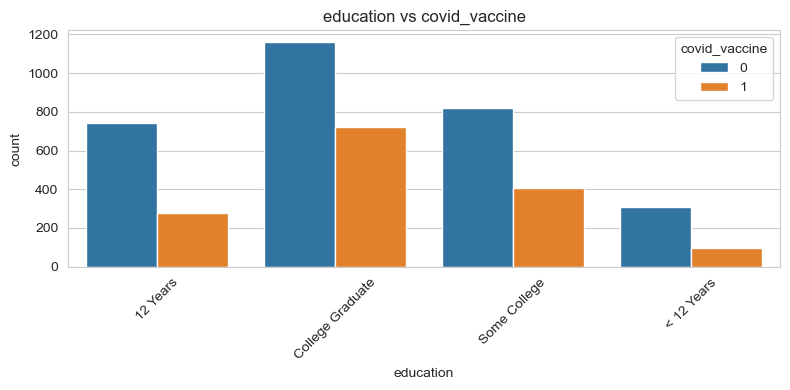

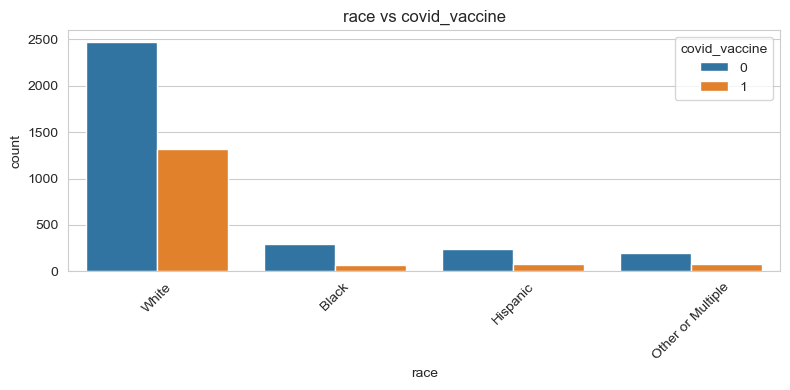

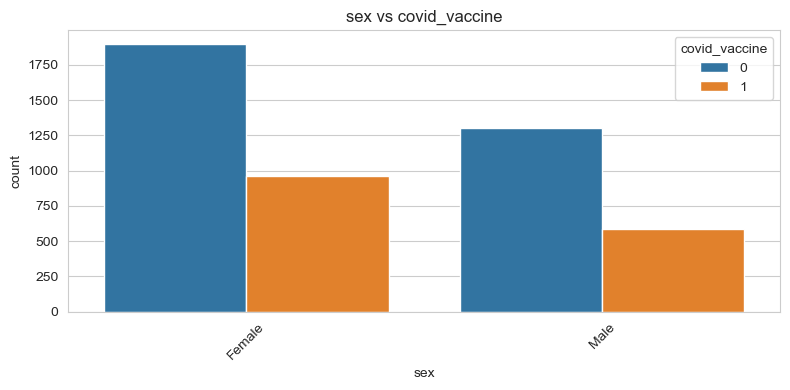

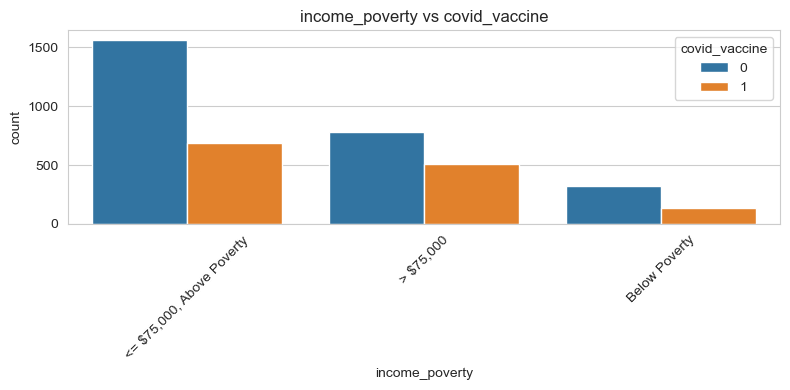

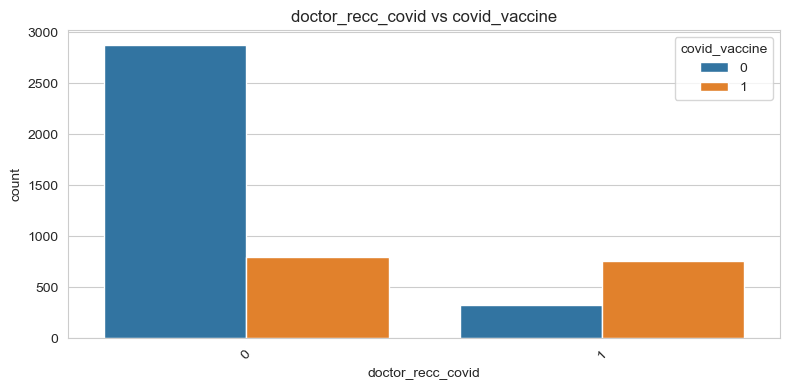

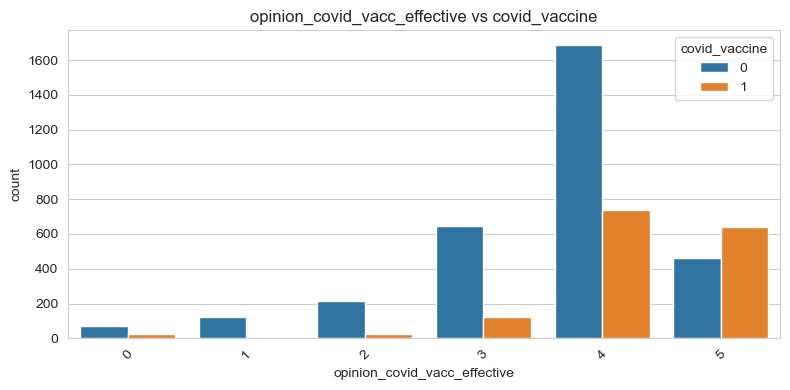

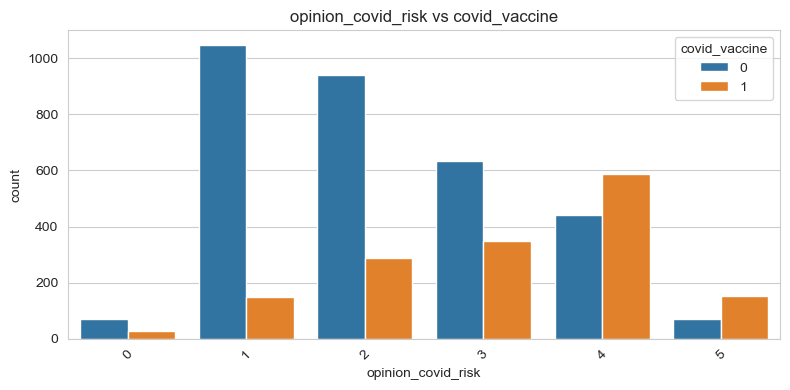

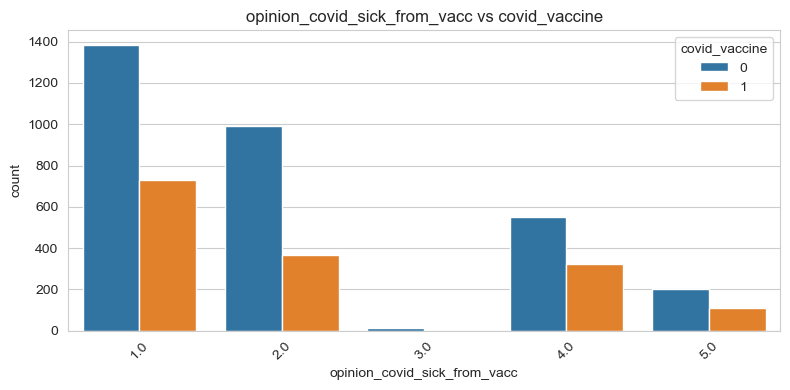

In [14]:
for col in ["age_group", "education", "race", "sex", "income_poverty",
            "doctor_recc_covid", "opinion_covid_vacc_effective",
            "opinion_covid_risk", "opinion_covid_sick_from_vacc"]:
    if col in train_df.columns:
        plt.figure(figsize=(8,4))
        sns.countplot(data=train_df, x=col, hue=target_col)
        plt.title(f"{col} vs covid_vaccine")
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

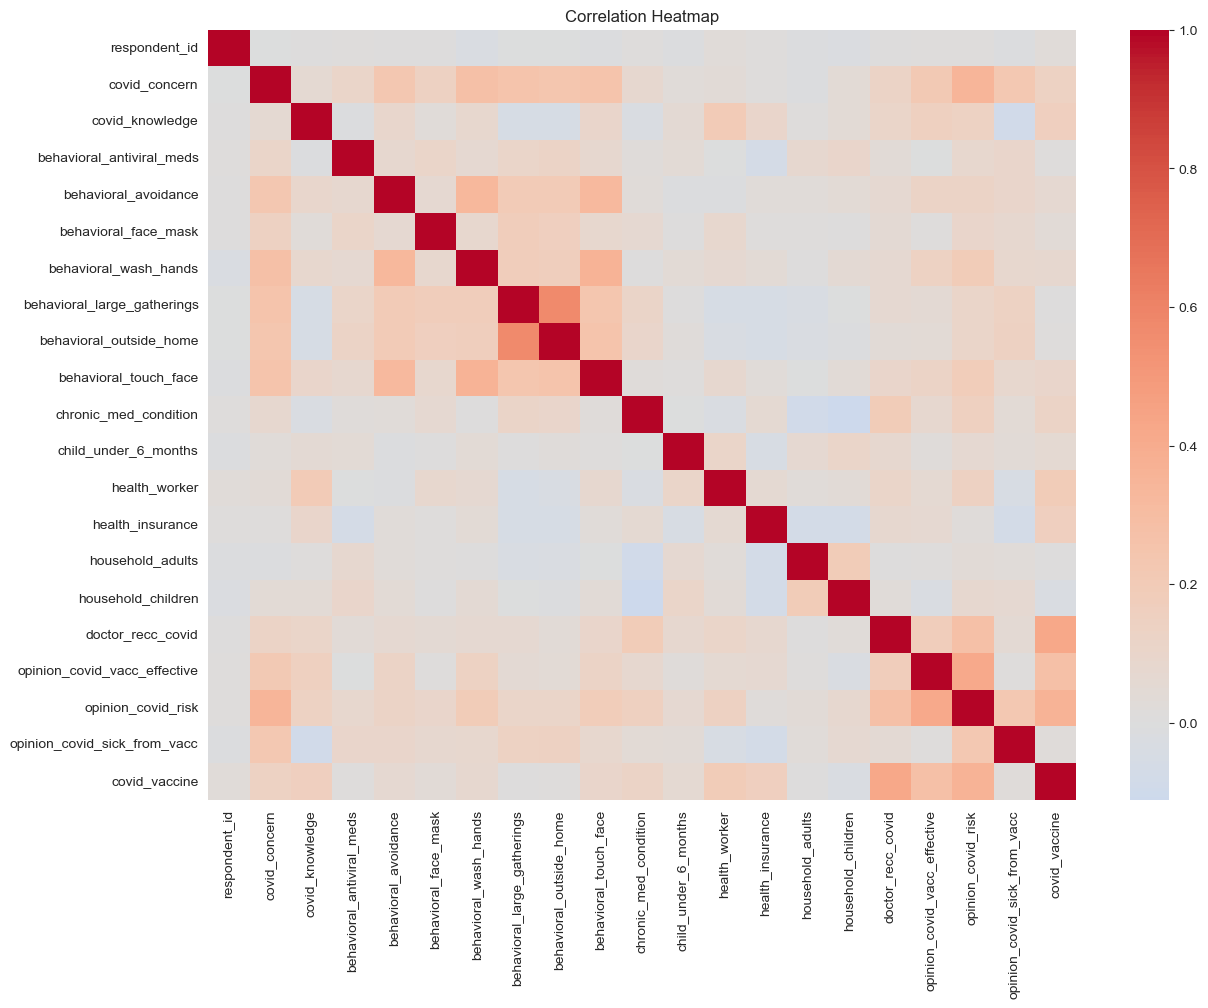

In [16]:
plt.figure(figsize=(14,10))
corr = train_df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [18]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

In [20]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_valid.shape)

(3804, 29) (952, 29)


In [22]:
knn_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier())
])

knn_param_grid = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 15],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

knn_grid = GridSearchCV(
    knn_pipeline,
    knn_param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

knn_grid.fit(X_train, y_train)
print("Best KNN params:", knn_grid.best_params_)
print("Best KNN CV score:", knn_grid.best_score_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best KNN params: {'model__metric': 'manhattan', 'model__n_neighbors': 15, 'model__weights': 'uniform'}
Best KNN CV score: 0.7728739885192614


In [24]:
knn_best = knn_grid.best_estimator_
knn_pred = knn_best.predict(X_valid)
print("KNN Accuracy:", accuracy_score(y_valid, knn_pred))
print(classification_report(y_valid, knn_pred))
print(confusion_matrix(y_valid, knn_pred))

KNN Accuracy: 0.7636554621848739
              precision    recall  f1-score   support

           0       0.77      0.92      0.84       641
           1       0.72      0.45      0.55       311

    accuracy                           0.76       952
   macro avg       0.75      0.68      0.70       952
weighted avg       0.76      0.76      0.75       952

[[588  53]
 [172 139]]


In [26]:
svc_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVC(probability=True))
])

svc_param_grid = {
    "model__C": [0.1, 1, 10],
    "model__kernel": ["linear", "rbf"],
    "model__gamma": ["scale", "auto"]
}

svc_grid = GridSearchCV(
    svc_pipeline,
    svc_param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

svc_grid.fit(X_train, y_train)

print("Best SVC params:", svc_grid.best_params_)
print("Best SVC CV score:", svc_grid.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best SVC params: {'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best SVC CV score: 0.7931132858427277


In [28]:
svc_best = svc_grid.best_estimator_
svc_pred = svc_best.predict(X_valid)
print("SVC Accuracy:", accuracy_score(y_valid, svc_pred))
print(classification_report(y_valid, svc_pred))
print(confusion_matrix(y_valid, svc_pred))


SVC Accuracy: 0.7846638655462185
              precision    recall  f1-score   support

           0       0.80      0.91      0.85       641
           1       0.74      0.52      0.61       311

    accuracy                           0.78       952
   macro avg       0.77      0.72      0.73       952
weighted avg       0.78      0.78      0.77       952

[[584  57]
 [148 163]]


KNN ROC-AUC: 0.7827525319662304
SVC ROC-AUC: 0.8168155665133359


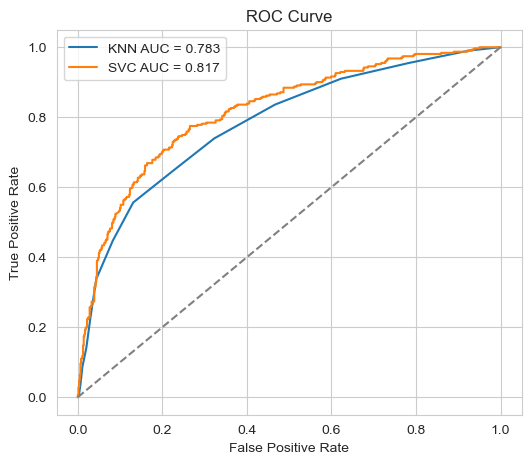

In [30]:
knn_probs = knn_best.predict_proba(X_valid)[:, 1]
svc_probs = svc_best.predict_proba(X_valid)[:, 1]

print("KNN ROC-AUC:", roc_auc_score(y_valid, knn_probs))
print("SVC ROC-AUC:", roc_auc_score(y_valid, svc_probs))

knn_fpr, knn_tpr, _ = roc_curve(y_valid, knn_probs)
svc_fpr, svc_tpr, _ = roc_curve(y_valid, svc_probs)

plt.figure(figsize=(6,5))
plt.plot(knn_fpr, knn_tpr, label=f"KNN AUC = {roc_auc_score(y_valid, knn_probs):.3f}")
plt.plot(svc_fpr, svc_tpr, label=f"SVC AUC = {roc_auc_score(y_valid, svc_probs):.3f}")
plt.plot([0,1], [0,1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [32]:
# =========================
# 14. Train best model on full training data
# =========================
best_model = svc_best  # or knn_best if KNN performs better

best_model.fit(X, y)

X_test = test_df.drop(columns=["respondent_id"], errors="ignore")
test_predictions = best_model.predict(X_test)

submission = pd.DataFrame({
    "respondent_id": test_df["respondent_id"],
    "covid_vaccine": test_predictions
})

submission.to_csv("submission.csv", index=False)
print(submission.head())


   respondent_id  covid_vaccine
0           4757              0
1           4758              0
2           4759              0
3           4760              0
4           4761              0
